In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report

import xgboost as xgb
import shap

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
np.random.seed(42)

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


In [2]:
ruta_archivo = "Dataset_UPL/marketing_promotion.csv"

df = pd.read_csv(ruta_archivo)

print(f'Shape: {df.shape}')
print(f'\nTipos de datos:')
print(df.dtypes)
print(f'\nValores nulos:')
print(df.isnull().sum())

df.head()

Shape: (64000, 9)

Tipos de datos:
recency            int64
history          float64
used_discount      int64
used_bogo          int64
zip_code             str
is_referral        int64
channel              str
offer                str
conversion         int64
dtype: object

Valores nulos:
recency          0
history          0
used_discount    0
used_bogo        0
zip_code         0
is_referral      0
channel          0
offer            0
conversion       0
dtype: int64


,recency,history,used_discount,used_bogo,zip_code,is_referral,channel,offer,conversion
0,10,142.44,1,0,Surburban,0,Phone,Buy One Get One,0
1,6,329.08,1,1,Rural,1,Web,No Offer,0
2,7,180.65,0,1,Surburban,1,Web,Buy One Get One,0
3,9,675.83,1,0,Rural,1,Web,Discount,0
4,2,45.34,1,0,Urban,0,Web,Buy One Get One,0


In [3]:
# --- Variables categóricas ---
print('=== Descripción de variables categóricas ===')
print(df.describe(include=object))

print('\n=== Distribución de la variable objetivo (conversion) ===')
print(df['conversion'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

=== Descripción de variables categóricas ===
         zip_code channel            offer
count       64000   64000            64000
unique          3       3                3
top     Surburban     Web  Buy One Get One
freq        28776   28217            21387

=== Distribución de la variable objetivo (conversion) ===
conversion
0    85.32%
1    14.68%
Name: proportion, dtype: str


=== Descripción de variables numéricas (con decimales) ===
            recency       history  used_discount     used_bogo   is_referral  \
count  64000.000000  64000.000000   64000.000000  64000.000000  64000.000000   
mean       5.763734    242.085656       0.551031      0.549719      0.502250   
std        3.507592    256.158608       0.497393      0.497526      0.499999   
min        1.000000     29.990000       0.000000      0.000000      0.000000   
25%        2.000000     64.660000       0.000000      0.000000      0.000000   
50%        6.000000    158.110000       1.000000      1.000000      1.000000   
75%        9.000000    325.657500       1.000000      1.000000      1.000000   
max       12.000000   3345.930000       1.000000      1.000000      1.000000   

         conversion  
count  64000.000000  
mean       0.146781  
std        0.353890  
min        0.000000  
25%        0.000000  
50%        0.000000  
75%        0.000000  
max        1.000000  


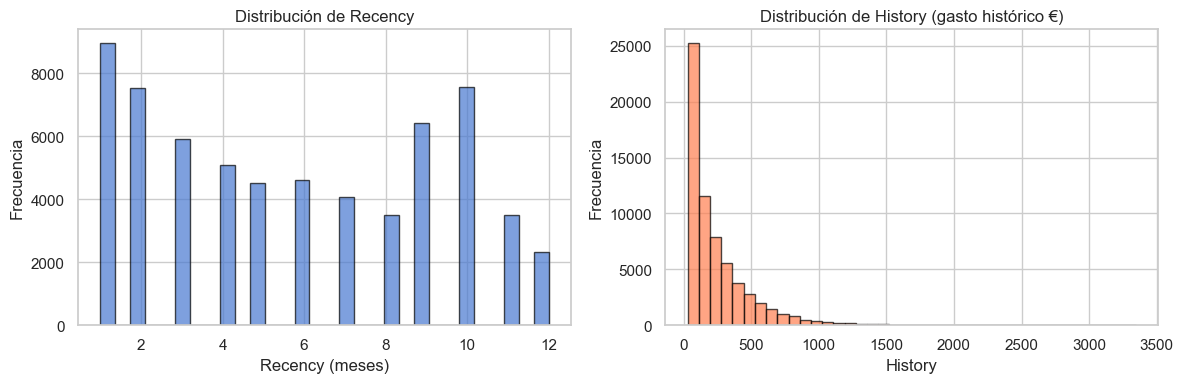

In [4]:
# --- Variables numéricas ---
print('=== Descripción de variables numéricas (con decimales) ===')
print(df.describe())

# Visualizar distribuciones
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['recency'], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_title('Distribución de Recency')
axes[0].set_xlabel('Recency (meses)')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(df['history'], bins=40, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_title('Distribución de History (gasto histórico €)')
axes[1].set_xlabel('History')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

=== Tasa de conversión por tipo de oferta ===
                 tasa_conversion  n_clientes
offer                                       
Buy One Get One            15.14       21387
Discount                   18.28       21307
No Offer                   10.62       21306


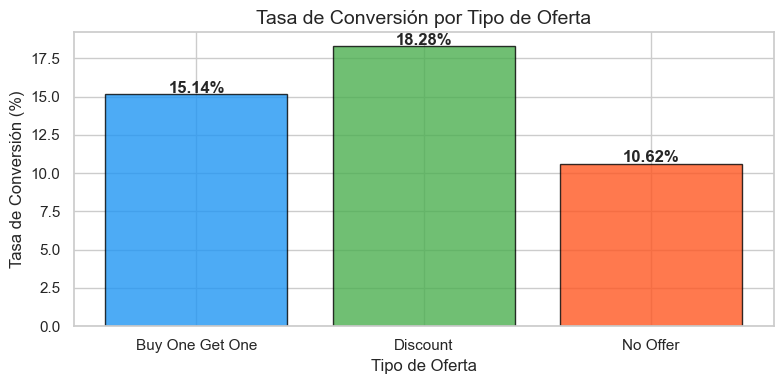

In [5]:
# --- Tasa de conversión por tipo de oferta ---
conv_por_oferta = df.groupby('offer')['conversion'].agg(['mean', 'count']).rename(
    columns={'mean': 'tasa_conversion', 'count': 'n_clientes'}
)
conv_por_oferta['tasa_conversion'] = conv_por_oferta['tasa_conversion'].mul(100).round(2)

print('=== Tasa de conversión por tipo de oferta ===')
print(conv_por_oferta)

# Gráfico
fig, ax = plt.subplots(figsize=(8, 4))
colores = ['#2196F3', '#4CAF50', '#FF5722']
bars = ax.bar(conv_por_oferta.index, conv_por_oferta['tasa_conversion'], color=colores, edgecolor='black', alpha=0.8)
for bar, val in zip(bars, conv_por_oferta['tasa_conversion']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{val:.2f}%',
            ha='center', fontweight='bold')
ax.set_title('Tasa de Conversión por Tipo de Oferta', fontsize=14)
ax.set_ylabel('Tasa de Conversión (%)')
ax.set_xlabel('Tipo de Oferta')
plt.tight_layout()
plt.show()

In [6]:
df_model = df.copy()

# 1. Renombrar columnas target y treatment
df_model = df_model.rename(columns={'offer': 'treatment', 'conversion': 'target'})

# 2. Mapear tratamiento: 'Buy One Get One' -> -1, 'No Offer' -> 0, 'Discount' -> 1
map_treatment = {'Buy One Get One': -1, 'No Offer': 0, 'Discount': 1}
df_model['treatment'] = df_model['treatment'].map(map_treatment)

# 3. One-hot encoding de variables categóricas (sin tocar las numéricas)
df_model = pd.get_dummies(df_model, columns=['zip_code', 'channel'], dtype=int)

# 4. Convertir binarias booleanas a int (used_discount, used_bogo, is_referral)
bool_cols = ['used_discount', 'used_bogo', 'is_referral']
df_model[bool_cols] = df_model[bool_cols].astype(int)

# NOTA: 'recency' e 'history' mantienen sus tipos originales (int y float)
# La normalización se aplica dentro del Pipeline de entrenamiento

print('Columnas resultantes:')
print(df_model.dtypes)
df_model.head()

Columnas resultantes:
recency                   int64
history                 float64
used_discount             int64
used_bogo                 int64
is_referral               int64
treatment                 int64
target                    int64
zip_code_Rural            int64
zip_code_Surburban        int64
zip_code_Urban            int64
channel_Multichannel      int64
channel_Phone             int64
channel_Web               int64
dtype: object


,recency,history,used_discount,used_bogo,is_referral,treatment,target,zip_code_Rural,zip_code_Surburban,zip_code_Urban,channel_Multichannel,channel_Phone,channel_Web
0,10,142.44,1,0,0,-1,0,0,1,0,0,1,0
1,6,329.08,1,1,1,0,0,1,0,0,0,0,1
2,7,180.65,0,1,1,-1,0,0,1,0,0,0,1
3,9,675.83,1,0,1,1,0,1,0,0,0,0,1
4,2,45.34,1,0,0,-1,0,0,0,1,0,0,1


In [7]:
def get_target_class(df: pd.DataFrame) -> pd.DataFrame:
    """
    Crea la columna target_class sobre una COPIA del DataFrame.
    Evita mutaciones in-place que causarían efectos secundarios silenciosos.

    Clases:
        0 = CN: Control Non-Responders  (control + no compra)
        1 = CR: Control Responders      (control + compra)
        2 = TN: Treatment Non-Responders (tratamiento + no compra)
        3 = TR: Treatment Responders    (tratamiento + compra)
    """
    out = df.copy()  # <-- CORRECCIÓN: operamos sobre copia, no sobre el original
    out['target_class'] = 0  # CN por defecto

    out.loc[(out['treatment'] == 0) & (out['target'] != 0), 'target_class'] = 1   # CR
    out.loc[(out['treatment'] != 0) & (out['target'] == 0), 'target_class'] = 2   # TN
    out.loc[(out['treatment'] != 0) & (out['target'] == 1), 'target_class'] = 3   # TR

    return out


# Separar datasets por tipo de oferta
df_model_discount = get_target_class(df_model[df_model['treatment'] >= 0].reset_index(drop=True))
df_model_bogo     = get_target_class(df_model[df_model['treatment'] <= 0].reset_index(drop=True))

print('=== Distribución de clases — Discount ===')
print(df_model_discount['target_class'].value_counts().sort_index())
print('\n=== Distribución de clases — BOGO ===')
print(df_model_bogo['target_class'].value_counts().sort_index())

=== Distribución de clases — Discount ===
target_class
0    19044
1     2262
2    17413
3     3894
Name: count, dtype: int64

=== Distribución de clases — BOGO ===
target_class
0    19044
1     2262
2    18149
3     3238
Name: count, dtype: int64


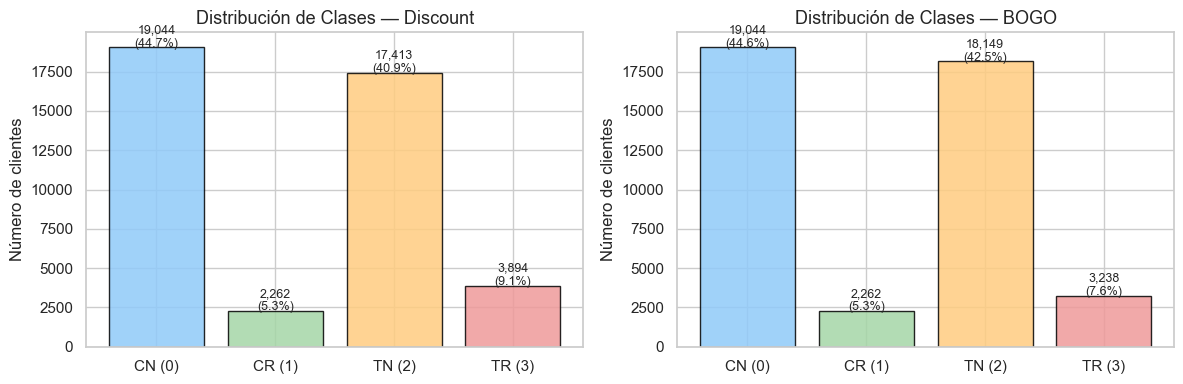


⚠ Si la clase TR (3) es muy minoritaria, se activará scale_pos_weight en el modelo.


In [8]:
# --- Visualizar desbalanceo de clases ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

labels = ['CN (0)', 'CR (1)', 'TN (2)', 'TR (3)']
colores = ['#90CAF9', '#A5D6A7', '#FFCC80', '#EF9A9A']

for ax, df_tmp, title in zip(
    axes,
    [df_model_discount, df_model_bogo],
    ['Distribución de Clases — Discount', 'Distribución de Clases — BOGO']
):
    counts = df_tmp['target_class'].value_counts().sort_index()
    bars = ax.bar(labels, counts.values, color=colores, edgecolor='black', alpha=0.85)
    for bar, val in zip(bars, counts.values):
        pct = val / len(df_tmp) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=9)
    ax.set_title(title, fontsize=13)
    ax.set_ylabel('Número de clientes')

plt.tight_layout()
plt.show()

print('\n⚠ Si la clase TR (3) es muy minoritaria, se activará scale_pos_weight en el modelo.')

In [9]:
def build_preprocessor(numeric_cols: list, binary_cols: list) -> ColumnTransformer:
    """Crea el preprocesador: escala numéricas, deja binarias sin tocar."""
    return ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numeric_cols),
            ('bin', 'passthrough', binary_cols),
        ],
        remainder='drop'
    )


def compute_scale_pos_weight(y: pd.Series) -> float:
    """
    Calcula scale_pos_weight para XGBoost en clasificación multiclase.
    Usamos la ratio clase mayoritaria / clase TR (3) como proxy.
    """
    counts = y.value_counts()
    majority = counts.max()
    minority = counts.get(3, 1)  # clase TR
    ratio = majority / minority
    print(f'   scale_pos_weight calculado: {ratio:.2f}  (mayoría={majority}, TR={minority})')
    return ratio


def uplift_split(df_model: pd.DataFrame):
    """Split estratificado por treatment (garantiza proporciones iguales en train/test)."""
    X = df_model.drop(['target', 'target_class'], axis=1)
    y = df_model['target_class']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.3,
        random_state=42,
        stratify=df_model['treatment']  # mantiene proporción tratamiento/control
    )
    return X_train, X_test, y_train, y_test


def uplift_model(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    y_train: pd.Series,
    y_test: pd.Series,
    n_iter_search: int = 30
) -> tuple:
    """
    Entrena el modelo de uplift con:
      - Pipeline de preprocesado (StandardScaler sobre numéricas)
      - RandomizedSearchCV con StratifiedKFold(5) sobre target_class
      - scale_pos_weight para corregir desbalanceo de la clase TR

    Devuelve: (result_df, best_model, best_params)
    """
    # 1. Columnas a tratar
    numeric_cols = ['recency', 'history']   # se escalan con StandardScaler
    binary_cols  = [c for c in X_train.drop('treatment', axis=1).columns
                    if c not in numeric_cols]

    # 2. Calcular corrección por desbalanceo
    spw = compute_scale_pos_weight(y_train)

    # 3. Construir pipeline
    preprocessor = build_preprocessor(numeric_cols, binary_cols)

    xgb_clf = xgb.XGBClassifier(
        objective='multi:softprob',
        num_class=4,
        scale_pos_weight=spw,
        random_state=42,
        eval_metric='mlogloss',
        verbosity=0
    )

    pipeline = Pipeline([
        ('prep', preprocessor),
        ('clf',  xgb_clf)
    ])

    # 4. Espacio de búsqueda de hiperparámetros
    param_dist = {
        'clf__n_estimators':      [100, 200, 300, 500],
        'clf__max_depth':         [3, 4, 5, 6],
        'clf__learning_rate':     [0.01, 0.05, 0.1, 0.2],
        'clf__subsample':         [0.7, 0.8, 0.9, 1.0],
        'clf__colsample_bytree':  [0.6, 0.7, 0.8, 1.0],
        'clf__min_child_weight':  [1, 3, 5],
        'clf__gamma':             [0, 0.1, 0.3],
        'clf__reg_alpha':         [0, 0.01, 0.1],
        'clf__reg_lambda':        [1, 1.5, 2],
    }

    # 5. Validación cruzada estratificada
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    search = RandomizedSearchCV(
        pipeline,
        param_distributions=param_dist,
        n_iter=n_iter_search,
        scoring='f1_macro',   # métrica balanceada para clases desiguales
        cv=cv,
        random_state=42,
        n_jobs=-1,
        verbose=1
    )

    X_train_notreat = X_train.drop('treatment', axis=1)
    X_test_notreat  = X_test.drop('treatment', axis=1)

    print('   Iniciando búsqueda de hiperparámetros (esto puede tardar 1-2 min)...')
    search.fit(X_train_notreat, y_train)

    best_model  = search.best_estimator_
    best_params = search.best_params_
    print(f'   Mejor F1-macro en CV: {search.best_score_:.4f}')

    # 6. Predicción sobre test
    uplift_proba = best_model.predict_proba(X_test_notreat)

    result = X_test.copy()
    result['proba_CN'] = uplift_proba[:, 0]
    result['proba_CR'] = uplift_proba[:, 1]
    result['proba_TN'] = uplift_proba[:, 2]
    result['proba_TR'] = uplift_proba[:, 3]

    # 7. Uplift score normalizado
    result['uplift_score'] = (
        result['proba_CN'] / (result['proba_CN'] + result['proba_CR']) +
        result['proba_TR'] / (result['proba_TN'] + result['proba_TR']) -
        result['proba_TN'] / (result['proba_TN'] + result['proba_TR']) -
        result['proba_CR'] / (result['proba_CN'] + result['proba_CR'])
    )

    result['target_class'] = y_test.values

    return result, best_model, best_params


def uplift(df_model: pd.DataFrame, n_iter_search: int = 30) -> tuple:
    """Función orquestadora principal. Devuelve (result, model, params)."""
    X_train, X_test, y_train, y_test = uplift_split(df_model)
    result, model, params = uplift_model(X_train, X_test, y_train, y_test, n_iter_search)
    return result, model, params


print('Funciones de entrenamiento definidas.')

Funciones de entrenamiento definidas.


In [10]:
print('=== ENTRENANDO MODELO BOGO ===')
resultado_bogo, modelo_bogo, params_bogo = uplift(df_model_bogo, n_iter_search=30)

print('\nMejores hiperparámetros BOGO:')
for k, v in params_bogo.items():
    print(f'  {k}: {v}')

=== ENTRENANDO MODELO BOGO ===
   scale_pos_weight calculado: 5.87  (mayoría=13313, TR=2267)
   Iniciando búsqueda de hiperparámetros (esto puede tardar 1-2 min)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
   Mejor F1-macro en CV: 0.2399

Mejores hiperparámetros BOGO:
  clf__subsample: 0.8
  clf__reg_lambda: 2
  clf__reg_alpha: 0
  clf__n_estimators: 500
  clf__min_child_weight: 3
  clf__max_depth: 6
  clf__learning_rate: 0.1
  clf__gamma: 0
  clf__colsample_bytree: 1.0


In [11]:
# Reporte de clasificación sobre el conjunto de test
print('=== Classification Report — BOGO ===')

# Columnas que NO son features del modelo
_extra_cols_bogo = ['target_class', 'proba_CN', 'proba_CR', 'proba_TN', 'proba_TR',
                    'uplift_score', 'treatment']
_feat_cols_bogo = [c for c in resultado_bogo.columns if c not in _extra_cols_bogo]

print(classification_report(
    resultado_bogo['target_class'],
    modelo_bogo.predict(resultado_bogo[_feat_cols_bogo]),
    target_names=['CN (0)', 'CR (1)', 'TN (2)', 'TR (3)']
))

=== Classification Report — BOGO ===
              precision    recall  f1-score   support

      CN (0)       0.45      0.56      0.50      5731
      CR (1)       0.10      0.01      0.01       661
      TN (2)       0.43      0.45      0.44      5445
      TR (3)       0.15      0.01      0.03       971

    accuracy                           0.44     12808
   macro avg       0.28      0.26      0.24     12808
weighted avg       0.40      0.44      0.41     12808



In [12]:
print('=== ENTRENANDO MODELO DISCOUNT ===')
resultado_discount, modelo_discount, params_discount = uplift(df_model_discount, n_iter_search=30)

print('\nMejores hiperparámetros Discount:')
for k, v in params_discount.items():
    print(f'  {k}: {v}')

=== ENTRENANDO MODELO DISCOUNT ===
   scale_pos_weight calculado: 4.91  (mayoría=13356, TR=2720)
   Iniciando búsqueda de hiperparámetros (esto puede tardar 1-2 min)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
   Mejor F1-macro en CV: 0.2398

Mejores hiperparámetros Discount:
  clf__subsample: 0.8
  clf__reg_lambda: 2
  clf__reg_alpha: 0
  clf__n_estimators: 500
  clf__min_child_weight: 3
  clf__max_depth: 6
  clf__learning_rate: 0.1
  clf__gamma: 0
  clf__colsample_bytree: 1.0


In [13]:
print('=== Classification Report — Discount ===')

_extra_cols_disc = ['target_class', 'proba_CN', 'proba_CR', 'proba_TN', 'proba_TR',
                    'uplift_score', 'treatment']
_feat_cols_disc = [c for c in resultado_discount.columns if c not in _extra_cols_disc]

print(classification_report(
    resultado_discount['target_class'],
    modelo_discount.predict(resultado_discount[_feat_cols_disc]),
    target_names=['CN (0)', 'CR (1)', 'TN (2)', 'TR (3)']
))


=== Classification Report — Discount ===
              precision    recall  f1-score   support

      CN (0)       0.44      0.57      0.50      5688
      CR (1)       0.08      0.01      0.01       704
      TN (2)       0.41      0.42      0.42      5218
      TR (3)       0.11      0.01      0.02      1174

    accuracy                           0.43     12784
   macro avg       0.26      0.25      0.24     12784
weighted avg       0.38      0.43      0.39     12784



In [14]:
columnas_analisis = ['proba_CN', 'proba_CR', 'proba_TN', 'proba_TR', 'uplift_score', 'target_class']

print('=== Top 20 Persuadibles — BOGO ===')
top_bogo = resultado_bogo.sort_values('uplift_score', ascending=False).head(20)
print(top_bogo[columnas_analisis].to_string())

print('\n=== Top 20 Persuadibles — Discount ===')
top_discount = resultado_discount.sort_values('uplift_score', ascending=False).head(20)
print(top_discount[columnas_analisis].to_string())

=== Top 20 Persuadibles — BOGO ===
       proba_CN  proba_CR  proba_TN  proba_TR  uplift_score  target_class
14120  0.437271  0.004339  0.046038  0.512352      1.815453             3
31739  0.566607  0.021336  0.085891  0.326166      1.510533             0
30287  0.423472  0.004131  0.137900  0.434497      1.498846             0
12879  0.411225  0.006543  0.139701  0.442530      1.488792             2
22244  0.315471  0.027359  0.136581  0.520589      1.424726             0
28218  0.187325  0.013052  0.182142  0.617481      1.414155             2
41276  0.400308  0.014168  0.154123  0.431402      1.405191             0
39948  0.300702  0.011174  0.180852  0.507272      1.402702             0
3080   0.300702  0.011174  0.180852  0.507272      1.402702             0
42506  0.300702  0.011174  0.180852  0.507272      1.402702             2
41262  0.225059  0.026798  0.149833  0.598310      1.386651             3
11701  0.233327  0.006158  0.219341  0.541175      1.371754             1
213

In [15]:
def compute_qini(
    result: pd.DataFrame,
    full_df: pd.DataFrame
) -> pd.DataFrame:
    """
    Calcula los valores de la curva Qini.
    Devuelve el DataFrame con columnas qini añadidas.
    """
    res = result.copy()
    res['target'] = full_df.loc[res.index, 'target'].values

    res = res.sort_values('uplift_score', ascending=False).reset_index(drop=True)

    res['c_target_tr']   = (res['target'] * (res['treatment'] != 0)).cumsum()
    res['c_target_ctrl'] = (res['target'] * (res['treatment'] == 0)).cumsum()
    res['c_tr']          = (res['treatment'] != 0).cumsum()
    res['c_ctrl']        = (res['treatment'] == 0).cumsum()

    # Evitar división por cero
    res['qini'] = res['c_target_tr'] - (
        res['c_target_ctrl'] * res['c_tr'] / res['c_ctrl'].replace(0, np.nan)
    ).fillna(0)

    return res


def auuc(qini_values: pd.Series) -> float:
    """Calcula el Area Under the Uplift Curve (integral trapezoidal normalizada).
    Compatible con NumPy >= 2.0 (np.trapezoid) y versiones anteriores (np.trapz).
    """
    trapz_fn = getattr(np, 'trapezoid', None) or getattr(np, 'trapz')
    return trapz_fn(qini_values) / len(qini_values)


def plot_qini(
    result: pd.DataFrame,
    full_df: pd.DataFrame,
    title: str = 'Curva Qini',
    color: str = 'blue'
) -> float:
    """
    Genera la curva Qini para un modelo y devuelve su AUUC.
    Función unificada para BOGO y Discount.
    """
    res = compute_qini(result, full_df)
    score_auuc = auuc(res['qini'])

    plt.figure(figsize=(10, 6))
    plt.plot(res['qini'], color=color, label=f'Modelo Uplift (XGBoost) — AUUC={score_auuc:.4f}', linewidth=2)
    plt.plot(
        [0, len(res)], [0, res['qini'].iloc[-1]],
        color='red', linestyle='--', label='Azar'
    )
    plt.fill_between(range(len(res)), res['qini'],
                     np.linspace(0, res['qini'].iloc[-1], len(res)),
                     alpha=0.1, color=color, label='Área AUUC')

    plt.title(title, fontsize=16)
    plt.xlabel('Número de Clientes Contactados (Ordenados por Score)')
    plt.ylabel('Ventas Extra Acumuladas')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return score_auuc


print('Funciones Qini / AUUC definidas.')

Funciones Qini / AUUC definidas.


In [16]:
# Celda de compatibilidad eliminada: el alias np.trapz/np.trapezoid
# ya está integrado directamente en la función auuc() de la celda anterior.
print('OK — compatibilidad NumPy gestionada internamente en auuc().')

OK — compatibilidad NumPy gestionada internamente en auuc().


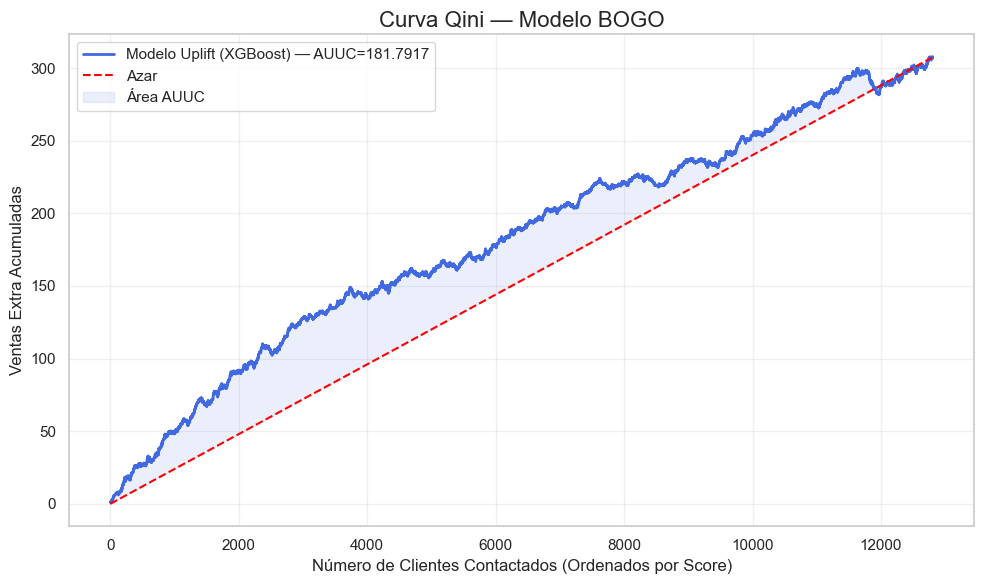

AUUC BOGO: 181.7917


In [17]:
auuc_bogo = plot_qini(
    resultado_bogo,
    df_model_bogo,
    title='Curva Qini — Modelo BOGO',
    color='royalblue'
)
print(f'AUUC BOGO: {auuc_bogo:.4f}')

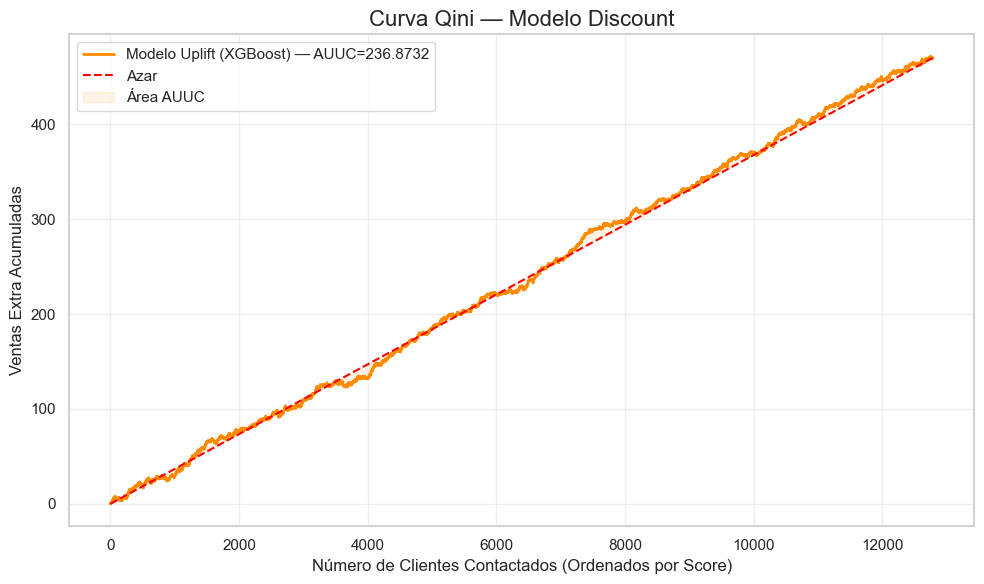

AUUC Discount: 236.8732


In [18]:
auuc_discount = plot_qini(
    resultado_discount,
    df_model_discount,
    title='Curva Qini — Modelo Discount',
    color='darkorange'
)
print(f'AUUC Discount: {auuc_discount:.4f}')

In [19]:
# --- Comparativa numérica de AUUC ---
print('=== Comparativa AUUC ===')
print(f'  BOGO:     {auuc_bogo:.4f}')
print(f'  Discount: {auuc_discount:.4f}')

ganador = 'BOGO' if auuc_bogo > auuc_discount else 'Discount'
diferencia = abs(auuc_bogo - auuc_discount)
print(f'\n→ El modelo {ganador} muestra mayor capacidad de ordenar persuadibles (Δ={diferencia:.4f})')

=== Comparativa AUUC ===
  BOGO:     181.7917
  Discount: 236.8732

→ El modelo Discount muestra mayor capacidad de ordenar persuadibles (Δ=55.0815)


In [20]:
def plot_decile_uplift(
    result_df: pd.DataFrame,
    title: str = 'Validación por Deciles'
) -> pd.DataFrame:
    """
    Calcula y visualiza el uplift real (TR% - CR%) por decil.
    Devuelve el DataFrame con las métricas por decil.
    """
    res = result_df.sort_values('uplift_score', ascending=False).reset_index(drop=True)
    res['decile'] = pd.qcut(res.index, 10, labels=range(1, 11))

    decile_records = []
    for i in range(1, 11):
        decile_data  = res[res['decile'] == i]
        treat_group  = decile_data[decile_data['treatment'] != 0]
        control_group = decile_data[decile_data['treatment'] == 0]

        rr_t = (treat_group['target_class'] == 3).mean() if len(treat_group) > 0 else 0
        rr_c = (control_group['target_class'] == 1).mean() if len(control_group) > 0 else 0

        actual_uplift = (rr_t - rr_c) * 100
        decile_records.append({
            'decile': i,
            'uplift_pct': actual_uplift,
            'n_treat': len(treat_group),
            'n_control': len(control_group),
            'rr_treatment_pct': rr_t * 100,
            'rr_control_pct': rr_c * 100
        })

    metrics_df = pd.DataFrame(decile_records)

    plt.figure(figsize=(11, 6))
    colors = plt.cm.RdYlGn(np.linspace(0.85, 0.15, 10))
    bars = plt.bar(
        range(1, 11),
        metrics_df['uplift_pct'],
        color=colors,
        edgecolor='black',
        alpha=0.85
    )

    for idx, val in enumerate(metrics_df['uplift_pct']):
        offset = 0.15 if val >= 0 else -0.55
        plt.text(idx + 1, val + offset, f'{val:.2f}%', ha='center', fontweight='bold', fontsize=9)

    plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
    plt.title(title, fontsize=15)
    plt.xlabel('Deciles (Ordenados por Score del Modelo)', fontsize=12)
    plt.ylabel('Uplift Real (TR% - CR%)', fontsize=12)
    plt.xticks(range(1, 11))
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    return metrics_df


print('Función de validación por deciles definida.')

Función de validación por deciles definida.


=== Validación por Deciles — BOGO ===


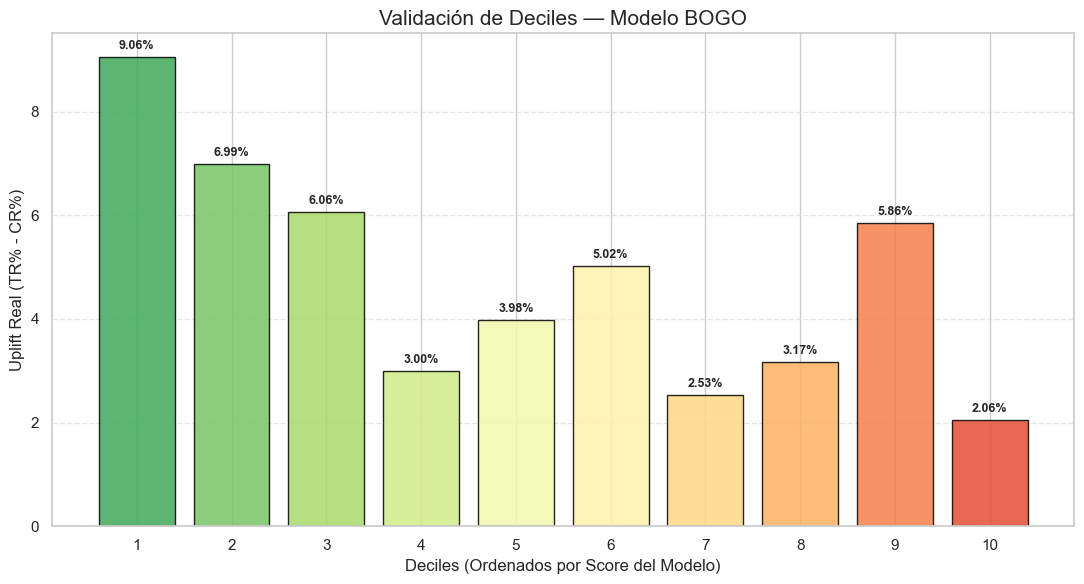

 decile  uplift_pct  n_treat  n_control
      1    9.056856      672        609
      2    6.988332      634        647
      3    6.057607      637        644
      4    3.000909      622        658
      5    3.983615      630        651
      6    5.017921      630        651
      7    2.528947      664        616
      8    3.174286      652        629
      9    5.857112      632        649
     10    2.059069      643        638

=== Validación por Deciles — Discount ===


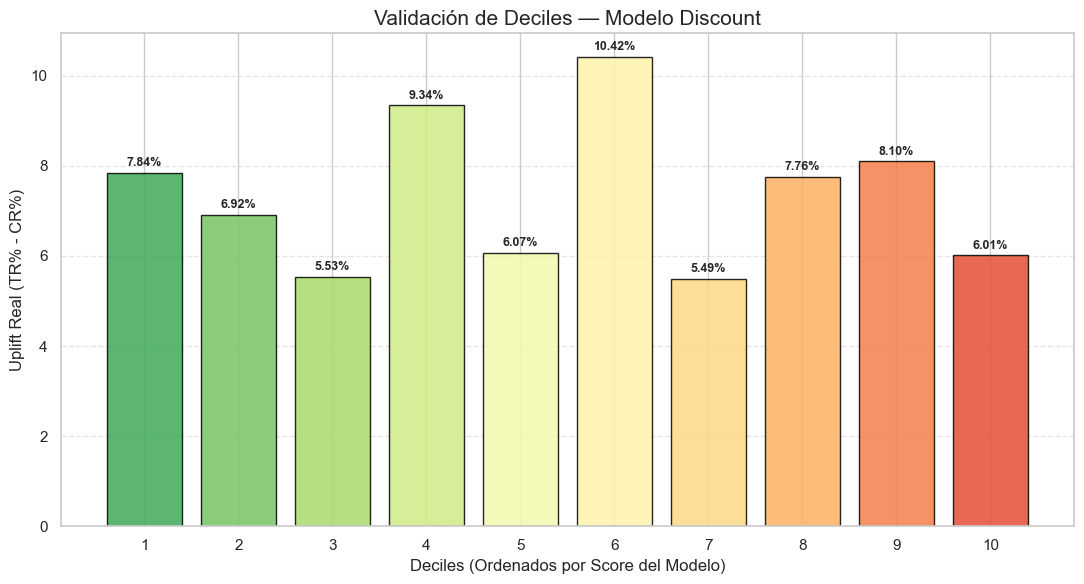

 decile  uplift_pct  n_treat  n_control
      1    7.843449      644        635
      2    6.918816      658        620
      3    5.527993      620        658
      4    9.340415      637        642
      5    6.066221      621        657
      6   10.421071      649        629
      7    5.490743      664        615
      8    7.759686      622        656
      9    8.098755      633        645
     10    6.013107      644        635


In [21]:
print('=== Validación por Deciles — BOGO ===')
deciles_bogo = plot_decile_uplift(resultado_bogo, title='Validación de Deciles — Modelo BOGO')
print(deciles_bogo[['decile', 'uplift_pct', 'n_treat', 'n_control']].to_string(index=False))

print('\n=== Validación por Deciles — Discount ===')
deciles_discount = plot_decile_uplift(resultado_discount, title='Validación de Deciles — Modelo Discount')
print(deciles_discount[['decile', 'uplift_pct', 'n_treat', 'n_control']].to_string(index=False))

In [22]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

def plot_shap_summary(model_pipeline, result_df: pd.DataFrame, title_suffix: str = '') -> None:
    """
    Genera el SHAP beeswarm plot específicamente para la clase TR (Persuadibles).
    Soluciona problemas de matrices dispersas, nombres de columnas con prefijos
    y visualización multiclase.
    """
    # 1. Extraer componentes del pipeline
    prep = model_pipeline.named_steps['prep']
    xgb_clf = model_pipeline.named_steps['clf']

    # 2. Aislar las columnas de entrada (features)
    _exclude = {'target_class', 'proba_CN', 'proba_CR', 'proba_TN', 'proba_TR', 'uplift_score', 'treatment'}
    feature_cols = [c for c in result_df.columns if c not in _exclude]
    X_explain = result_df[feature_cols]

    # 3. Transformación y conversión a matriz DENSA
    # SHAP a veces no dibuja puntos si la matriz es Sparse (dispersa)
    X_transformed = prep.transform(X_explain)
    if hasattr(X_transformed, "toarray"):
        X_transformed = X_transformed.toarray()

    # 4. Obtener y limpiar nombres de columnas
    try:
        # Extraemos nombres y quitamos prefijos como 'bin__' o 'num__'
        raw_names = prep.get_feature_names_out()
        feature_names = [name.split('__')[-1] for name in raw_names]
    except Exception:
        # Fallback si el preprocesador no soporta get_feature_names_out
        feature_names = feature_cols 

    # 5. Calcular valores SHAP
    explainer = shap.TreeExplainer(xgb_clf)
    shap_values = explainer.shap_values(X_transformed)

    # 6. Selección de la clase TR (Persuadibles)
    # En modelos Uplift de 4 clases (CN, CR, TN, TR), TR es el índice 3.
    if isinstance(shap_values, list):
        # Si devuelve una lista de arrays (uno por clase)
        shap_tr = shap_values[3]
    elif len(shap_values.shape) == 3:
        # Si devuelve un array 3D: (muestras, variables, clases)
        shap_tr = shap_values[:, :, 3]
    else:
        # Fallback si ya es 2D
        shap_tr = shap_values

    # 7. Crear DataFrame para que SHAP asocie nombres correctamente
    X_display = pd.DataFrame(X_transformed, columns=feature_names)

    # 8. Renderizar el gráfico
    print(f'Generando SHAP para Clase TR (Persuadibles) {title_suffix}...')
    
    # Ajustamos el tamaño de la figura para que sea legible
    plt.figure(figsize=(12, 8))
    
    shap.summary_plot(
        shap_tr, 
        X_display, 
        plot_type="dot", # 'dot' genera el beeswarm
        show=False,
        max_display=12
    )
    
    plt.title(f"SHAP - Importancia en Persuadibles (TR) {title_suffix}")
    plt.tight_layout()
    plt.show()

# --- Ejemplo de uso ---
# plot_shap_summary(modelo_bogo, resultado_bogo, title_suffix='- BOGO')

Generando SHAP para Clase TR (Persuadibles) — BOGO...


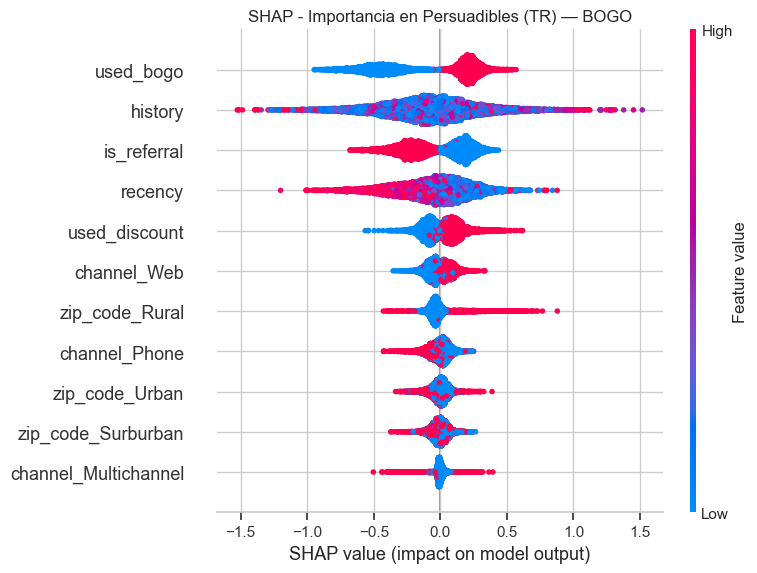

In [23]:
plot_shap_summary(modelo_bogo, resultado_bogo, title_suffix='— BOGO')

Generando SHAP para Clase TR (Persuadibles) — Discount...


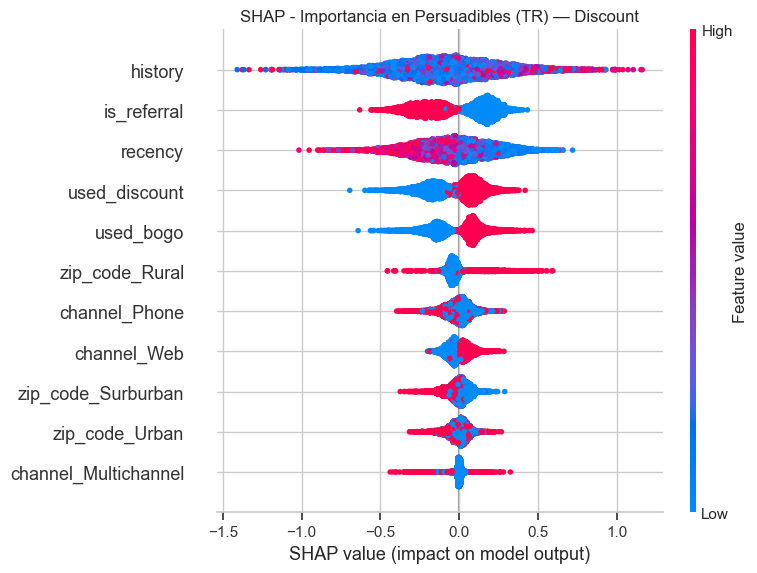

In [24]:
plot_shap_summary(modelo_discount, resultado_discount, title_suffix='— Discount')

In [25]:
print('=' * 55)
print('           RESUMEN EJECUTIVO DEL MODELO')
print('=' * 55)

for nombre, resultado, deciles, auuc_val in [
    ('BOGO',     resultado_bogo,     deciles_bogo,     auuc_bogo),
    ('Discount', resultado_discount, deciles_discount, auuc_discount),
]:
    n_test       = len(resultado)
    n_persuad    = (resultado['target_class'] == 3).sum()
    avg_uplift_d1 = deciles[deciles['decile'] == 1]['uplift_pct'].values[0]

    print(f'\n--- Modelo {nombre} ---')
    print(f'  Clientes en test:         {n_test:,}')
    print(f'  Persuadibles reales (TR): {n_persuad:,} ({n_persuad/n_test*100:.1f}%)')
    print(f'  AUUC:                     {auuc_val:.4f}')
    print(f'  Uplift real decil 1:      {avg_uplift_d1:.2f}%')

print('\n' + '=' * 55)
print(f'Modelo con mayor AUUC: {"BOGO" if auuc_bogo > auuc_discount else "Discount"}')
print('=' * 55)

           RESUMEN EJECUTIVO DEL MODELO

--- Modelo BOGO ---
  Clientes en test:         12,808
  Persuadibles reales (TR): 971 (7.6%)
  AUUC:                     181.7917
  Uplift real decil 1:      9.06%

--- Modelo Discount ---
  Clientes en test:         12,784
  Persuadibles reales (TR): 1,174 (9.2%)
  AUUC:                     236.8732
  Uplift real decil 1:      7.84%

Modelo con mayor AUUC: Discount


In [26]:
# =============================================================
# EXPORTACIÓN PARA POWER BI — 64.000 registros completos
# Aplica los modelos ya entrenados (sin reentrenar)
# =============================================================

def exportar_powerbi(
    df_original: pd.DataFrame,
    df_model_full: pd.DataFrame,
    modelo_bogo,
    modelo_discount,
    ruta_salida: str = 'uplift_powerbi.csv'
) -> pd.DataFrame:
    """
    Genera el dataset completo de 64.000 registros para Power BI.

    Lógica de asignación de modelo:
      - Clientes con oferta BOGO (treatment == -1) o control (treatment == 0)
        → scored con modelo_bogo
      - Clientes con oferta Discount (treatment == 1) o control (treatment == 0)
        → scored con modelo_discount
      - El grupo de control (treatment == 0) aparece en ambos modelos;
        el score final usa el modelo BOGO como referencia para el control
        (convención: el control se puntúa con el modelo de su grupo asignado
        según el dataset original, que ya está en df_model_full).

    Estrategia:
      Iteramos sobre TODOS los registros y aplicamos el pipeline correcto
      según el treatment de cada cliente, usando predict_proba() sin
      reentrenar ningún modelo.
    """

    # ── 1. Columnas que el pipeline conoce (igual que en uplift_model) ──
    def get_feature_cols(modelo):
        prep = modelo.named_steps['prep']
        num_cols = list(prep.transformers_[0][2])  # ['recency', 'history']
        bin_cols = list(prep.transformers_[1][2])  # binarias + dummies
        return num_cols + bin_cols

    feat_bogo     = get_feature_cols(modelo_bogo)
    feat_discount = get_feature_cols(modelo_discount)

    # ── 2. Preparar el df_model_full (tiene target_class ya calculado) ──
    # Máscaras por tipo de cliente
    mask_bogo     = df_model_full['treatment'] <= 0   # BOGO (-1) + Control (0)
    mask_discount = df_model_full['treatment'] >= 0   # Discount (1) + Control (0)
    mask_control  = df_model_full['treatment'] == 0

    # ── 3. Calcular probabilidades con cada modelo ──
    def score_group(df_sub, modelo, feat_cols):
        X = df_sub[feat_cols]
        proba = modelo.predict_proba(X)
        return pd.DataFrame({
            'proba_CN': proba[:, 0],
            'proba_CR': proba[:, 1],
            'proba_TN': proba[:, 2],
            'proba_TR': proba[:, 3],
        }, index=df_sub.index)

    scores_bogo     = score_group(df_model_full[mask_bogo],     modelo_bogo,     feat_bogo)
    scores_discount = score_group(df_model_full[mask_discount], modelo_discount, feat_discount)

    # ── 4. Combinar: cada registro recibe el score de SU modelo ──
    # BOGO (-1): solo modelo bogo
    # Discount (1): solo modelo discount
    # Control (0): promedio de ambos modelos (fue grupo de control para los dos)
    scores_todos = pd.DataFrame(index=df_model_full.index,
                                 columns=['proba_CN','proba_CR','proba_TN','proba_TR'],
                                 dtype=float)

    idx_bogo_only     = df_model_full.index[df_model_full['treatment'] == -1]
    idx_discount_only = df_model_full.index[df_model_full['treatment'] ==  1]
    idx_control       = df_model_full.index[mask_control]

    scores_todos.loc[idx_bogo_only]     = scores_bogo.loc[idx_bogo_only].values
    scores_todos.loc[idx_discount_only] = scores_discount.loc[idx_discount_only].values

    # Control: media de las probabilidades de ambos modelos
    ctrl_bogo     = scores_bogo.loc[idx_control]
    ctrl_discount = scores_discount.loc[idx_control]
    scores_todos.loc[idx_control] = ((ctrl_bogo.values + ctrl_discount.values) / 2)

    # ── 5. Calcular uplift_score y target_class ──
    CN = scores_todos['proba_CN'].astype(float)
    CR = scores_todos['proba_CR'].astype(float)
    TN = scores_todos['proba_TN'].astype(float)
    TR = scores_todos['proba_TR'].astype(float)

    uplift_score = (
        CN / (CN + CR) +
        TR / (TN + TR) -
        TN / (TN + TR) -
        CR / (CN + CR)
    )

    target_class = scores_todos[['proba_CN','proba_CR','proba_TN','proba_TR']].values.argmax(axis=1)

    # ── 6. Construir el DataFrame de salida ──
    # Partir del df ORIGINAL (sin dummies, con nombres originales)
    export = df_original.copy().reset_index(drop=True)

    # Mapear treatment e offer de vuelta a etiquetas legibles
    map_treatment_inv = {-1: 'Buy One Get One', 0: 'No Offer', 1: 'Discount'}

    # df_original ya tiene 'offer' y 'conversion' con sus nombres originales
    # Renombramos para que Power BI tenga nombres claros
    export = export.rename(columns={
        'offer':      'tratamiento',
        'conversion': 'conversion_real'
    })

    # ── 7. Añadir columnas nuevas ──
    export.insert(0, 'id_cliente', range(1, len(export) + 1))

    # Columna 'test': 1 si recibió oferta (tratamiento), 0 si es control
    export['test'] = df_model_full['treatment'].apply(lambda x: 0 if x == 0 else 1).values

    export['target_class']  = target_class
    export['uplift_score']  = uplift_score.values
    export['proba_CN']      = CN.values
    export['proba_CR']      = CR.values
    export['proba_TN']      = TN.values
    export['proba_TR']      = TR.values

    # Etiqueta descriptiva de la clase
    map_clase = {
        0: 'CN - Control No Compra',
        1: 'CR - Control Compra',
        2: 'TN - Tratamiento No Compra',
        3: 'TR - Tratamiento Compra (Persuadible)'
    }
    export['target_class_desc'] = export['target_class'].map(map_clase)

    # ── 8. Exportar con separador ';' y decimal ',' para Power BI (es-ES) ──
    export.to_csv(
        ruta_salida,
        sep=';',
        decimal=',',
        index=False,
        encoding='utf-8-sig'   # BOM para que Excel/Power BI detecte UTF-8 correctamente
    )

    print(f'✓ Dataset exportado: {ruta_salida}')
    print(f'  Registros: {len(export):,}')
    print(f'  Columnas:  {list(export.columns)}')
    print(f'\n  Distribución de target_class:')
    print(export['target_class_desc'].value_counts().to_string())
    print(f'\n  Distribución de test (0=control, 1=tratamiento):')
    print(export['test'].value_counts().to_string())
    print(f'\n  Uplift score — estadísticas:')
    print(export['uplift_score'].describe().round(4).to_string())

    return export


# ── EJECUCIÓN ──
# df          → DataFrame original de 64.000 registros (cargado en celda 2)
# df_model    → versión preprocesada con dummies (celda 6)
# Necesitamos df_model con target_class, que viene de df_model_discount + df_model_bogo
# Los reconstruimos sobre el df_model completo:

df_model_completo = get_target_class(df_model)  # aplica sobre los 64.000

df_export = exportar_powerbi(
    df_original  = df,                  # DataFrame original con columnas originales
    df_model_full= df_model_completo,   # DataFrame preprocesado completo
    modelo_bogo     = modelo_bogo,
    modelo_discount = modelo_discount,
    ruta_salida  = 'uplift_powerbi.csv'
)

df_export.head(10)


✓ Dataset exportado: uplift_powerbi.csv
  Registros: 64,000
  Columnas:  ['id_cliente', 'recency', 'history', 'used_discount', 'used_bogo', 'zip_code', 'is_referral', 'channel', 'tratamiento', 'conversion_real', 'test', 'target_class', 'uplift_score', 'proba_CN', 'proba_CR', 'proba_TN', 'proba_TR', 'target_class_desc']

  Distribución de target_class:
target_class_desc
CN - Control No Compra                   33874
TN - Tratamiento No Compra               29353
TR - Tratamiento Compra (Persuadible)      588
CR - Control Compra                        185

  Distribución de test (0=control, 1=tratamiento):
test
1    42694
0    21306

  Uplift score — estadísticas:
count    64000.0000
mean         0.1203
std          0.2589
min         -1.6131
25%         -0.0061
50%          0.1037
75%          0.2378
max          1.8155


,id_cliente,recency,history,used_discount,used_bogo,zip_code,is_referral,channel,tratamiento,conversion_real,test,target_class,uplift_score,proba_CN,proba_CR,proba_TN,proba_TR,target_class_desc
0,1,10,142.44,1,0,Surburban,0,Phone,Buy One Get One,0,1,0,0.131986,0.558780,0.009938,0.395283,0.035998,CN - Control No Compra
1,2,6,329.08,1,1,Rural,1,Web,No Offer,0,0,2,0.106932,0.387017,0.075655,0.420737,0.116591,TN - Tratamiento No Compra
2,3,7,180.65,0,1,Surburban,1,Web,Buy One Get One,0,1,2,-0.065113,0.416935,0.061538,0.471431,0.050096,TN - Tratamiento No Compra
3,4,9,675.83,1,0,Rural,1,Web,Discount,0,1,2,-0.105479,0.322757,0.028994,0.629004,0.019245,TN - Tratamiento No Compra
4,5,2,45.34,1,0,Urban,0,Web,Buy One Get One,0,1,2,0.126624,0.356525,0.036769,0.511574,0.095132,TN - Tratamiento No Compra
5,6,6,134.83,0,1,Surburban,0,Phone,Buy One Get One,1,1,2,0.214549,0.425820,0.013914,0.482436,0.077830,TN - Tratamiento No Compra
6,7,9,280.20,1,0,Surburban,1,Phone,Buy One Get One,0,1,0,-0.002175,0.531951,0.012083,0.446334,0.009632,CN - Control No Compra
7,8,9,46.42,0,1,Urban,0,Phone,Buy One Get One,0,1,0,0.288754,0.506516,0.010623,0.403228,0.079633,CN - Control No Compra
8,9,9,675.07,1,1,Rural,1,Phone,Discount,0,1,2,0.047530,0.250850,0.005554,0.709819,0.033777,TN - Tratamiento No Compra
9,10,10,32.84,0,1,Urban,1,Web,Buy One Get One,0,1,2,-0.051744,0.398501,0.028295,0.550033,0.023171,TN - Tratamiento No Compra
